## Data Preparation and Exploratory Analysis

Before evaluating the LLM, we first clean and analyze the Amazon reviews dataset.

The goal of this step is to prepare a balanced dataset suitable for sentiment classification.

The script performs the following steps:

Load the raw dataset

The dataset contains Amazon product reviews and star ratings.

Select relevant columns

reviewText → the text of the review

overall → the star rating (1–5)

Convert ratings to sentiment labels

Ratings 4–5 → Positive

Ratings 1–2 → Negative

Ratings 3 → Neutral (removed)

Clean the text data

Remove missing reviews

Remove duplicates

Filter very short reviews (less than a minimum word count)

Balance the dataset

Ensure the number of Positive and Negative reviews is equal

This prevents bias toward the majority class.

Limit dataset size (optional)

For faster LLM evaluation, the dataset can be capped to a fixed number of samples per class.

Save the processed dataset

The cleaned dataset is exported as
amazon_reviews_llm_ready.csv

This prepared dataset will then be used to evaluate the LLM’s ability to classify review sentiment.

=== RAW DATA ===
Raw shape: (4915, 12)
       reviewerID        asin reviewerName helpful  \
0  A3SBTW3WS4IQSN  B007WTAJTO          NaN  [0, 0]   
1  A18K1ODH1I2MVB  B007WTAJTO         0mie  [0, 0]   
2  A2FII3I2MBMUIA  B007WTAJTO          1K3  [0, 0]   

                                          reviewText  overall  \
0                                         No issues.      4.0   
1  Purchased this for my device, it worked as adv...      5.0   
2  it works as expected. I should have sprung for...      4.0   

                     summary  unixReviewTime  reviewTime  day_diff  \
0                 Four Stars      1406073600  2014-07-23       138   
1              MOAR SPACE!!!      1382659200  2013-10-25       409   
2  nothing to really say....      1356220800  2012-12-23       715   

   helpful_yes  total_vote  
0            0           0  
1            0           0  
2            0           0   

Dropped missing rows: 1 | Shape: (4914, 2)
Removed empty reviews: 0 | Shape: (4914, 

C:\Users\erict\AppData\Local\Temp\ipykernel_12628\613345380.py:103: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n, random_state=SEED))


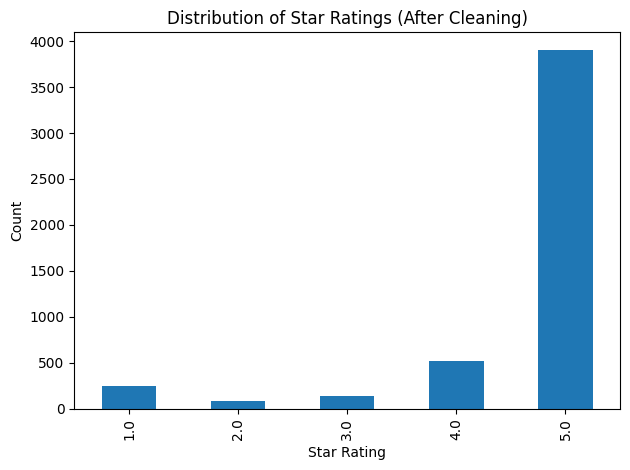

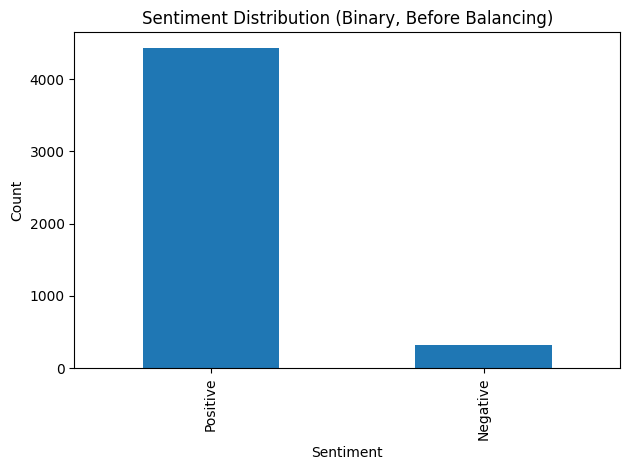

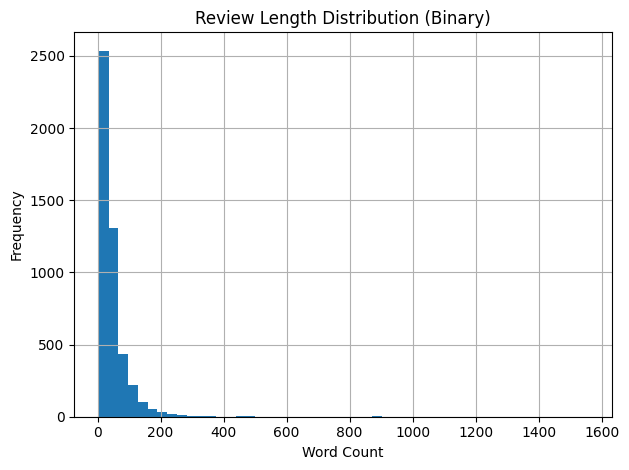

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
RAW_PATH = "../data/amazon_reviews.csv"
OUT_PATH = "../data/amazon_reviews_llm_ready.csv"

MIN_WORDS = 4          # filter out tiny reviews like "good"
SEED = 42
MAKE_PLOTS = True

# If you want to cap size for fast LLM testing:
# Set to an int like 400 (means 400 pos + 400 neg = 800 total)
# Or set to None to use max balanced size.
CAP_PER_CLASS = 400

# =========================
# 1) LOAD
# =========================
df = pd.read_csv(RAW_PATH)
print("=== RAW DATA ===")
print("Raw shape:", df.shape)
print(df.head(3), "\n")

# =========================
# 2) KEEP NEEDED COLS + CLEAN
# =========================
df = df[["reviewText", "overall"]].copy()

# drop missing
before = len(df)
df = df.dropna(subset=["reviewText", "overall"])
print(f"Dropped missing rows: {before - len(df)} | Shape: {df.shape}")

# numeric rating
df["overall"] = pd.to_numeric(df["overall"], errors="coerce")
df = df.dropna(subset=["overall"])

# strip text + remove empty
df["reviewText"] = df["reviewText"].astype(str).str.strip()
before = len(df)
df = df[df["reviewText"] != ""]
print(f"Removed empty reviews: {before - len(df)} | Shape: {df.shape}")

# remove duplicate texts
dup_count = df.duplicated(subset=["reviewText"]).sum()
df = df.drop_duplicates(subset=["reviewText"])
print(f"Removed duplicates (reviewText): {dup_count} | Shape: {df.shape}")

# lengths
df["char_len"] = df["reviewText"].str.len()
df["word_len"] = df["reviewText"].str.split().str.len()

# remove super short reviews
before = len(df)
df = df[df["word_len"] >= MIN_WORDS]
print(f"Removed short reviews (<{MIN_WORDS} words): {before - len(df)} | Shape: {df.shape}\n")

# =========================
# 3) STAR DISTRIBUTION (EDA)
# =========================
print("=== STAR DISTRIBUTION ===")
print(df["overall"].value_counts().sort_index(), "\n")

# =========================
# 4) CREATE BINARY SENTIMENT LABELS
# =========================
def to_sentiment(r):
    if r <= 2:
        return "Negative"
    if r >= 4:
        return "Positive"
    return "Neutral"

df["sentiment"] = df["overall"].apply(to_sentiment)

print("=== SENTIMENT COUNTS (WITH NEUTRAL) ===")
print(df["sentiment"].value_counts(), "\n")

# drop neutral (3-star)
df_bin = df[df["sentiment"] != "Neutral"].copy()
print("=== BINARY DATASET ===")
print("Binary shape:", df_bin.shape)
print(df_bin["sentiment"].value_counts(), "\n")

# length stats
print("=== LENGTH STATS (BINARY) ===")
print(df_bin[["char_len", "word_len"]].describe(), "\n")

# =========================
# 5) BALANCE FOR FAIR TESTING
# =========================
counts = df_bin["sentiment"].value_counts()
n = int(counts.min())

if CAP_PER_CLASS is not None:
    n = min(n, int(CAP_PER_CLASS))

df_bal = (
    df_bin.groupby("sentiment", group_keys=False)
    .apply(lambda x: x.sample(n, random_state=SEED))
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("=== BALANCED DATASET (LLM READY) ===")
print("Final shape:", df_bal.shape)
print(df_bal["sentiment"].value_counts(), "\n")

# =========================
# 6) SAVE FINAL FILE
# =========================
# Keep only what you need for LLM testing + useful metadata
df_bal = df_bal[["reviewText", "overall", "sentiment", "word_len", "char_len"]].copy()
df_bal.to_csv(OUT_PATH, index=False)
print(f"Saved LLM-ready dataset -> {OUT_PATH}\n")

# =========================
# 7) PLOTS (FOR SLIDES)
# =========================
if MAKE_PLOTS:
    # Star rating distribution
    df["overall"].value_counts().sort_index().plot(kind="bar")
    plt.title("Distribution of Star Ratings (After Cleaning)")
    plt.xlabel("Star Rating")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Sentiment distribution (binary)
    df_bin["sentiment"].value_counts().plot(kind="bar")
    plt.title("Sentiment Distribution (Binary, Before Balancing)")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Word length histogram
    df_bin["word_len"].hist(bins=50)
    plt.title("Review Length Distribution (Binary)")
    plt.xlabel("Word Count")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()